In [321]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [322]:
IMAGE_PATH= "./data/development_set/3f_png.rf.81c7e132365ef95bb19380ca389025f6.jpg"

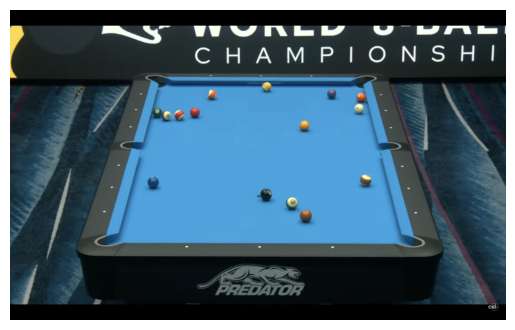

In [323]:
img = cv2.imread(IMAGE_PATH)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

Shape before resizing: (2100, 3360, 3)
Shape after resizing: (500, 800, 3)


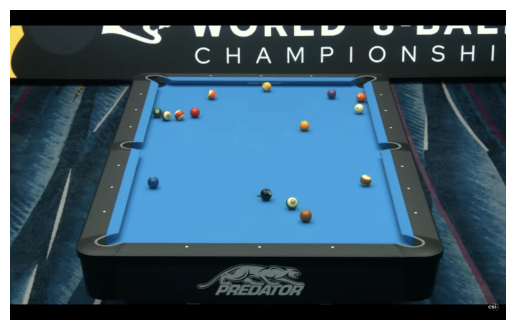

In [324]:
print(f"Shape before resizing: {img.shape}")
#resize
height, width = img.shape[:2]
img = cv2.resize(img, (800, int(800 * height / width)))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")

print(f"Shape after resizing: {img.shape}")

(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

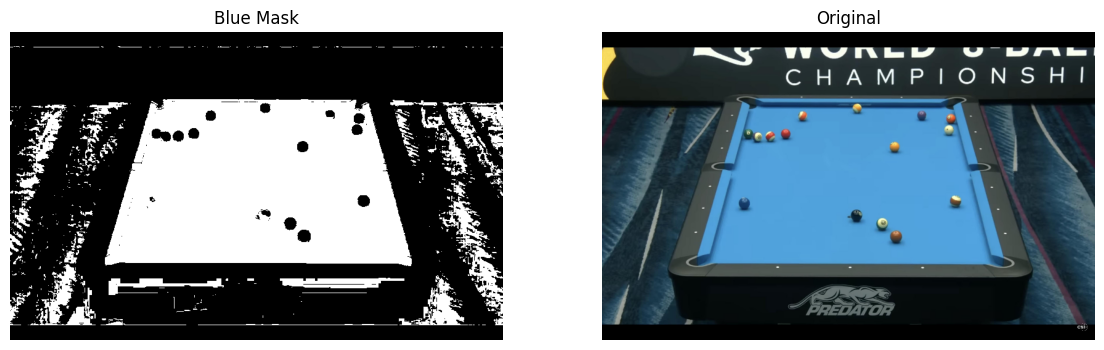

In [325]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

#  range for a blue in general according to the range on opencv . 
lower_blue = np.array([100, 150, 0])
upper_blue = np.array([140, 255, 255])

# create a mask of the blue table
table_mask = cv2.inRange(hsv, lower_blue, upper_blue)

f, axarr = plt.subplots(1, 2, figsize=(14, 4))

axarr[0].imshow(table_mask, cmap="gray")
axarr[0].set_title("Blue Mask")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Original")
axarr[1].axis("off")


(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

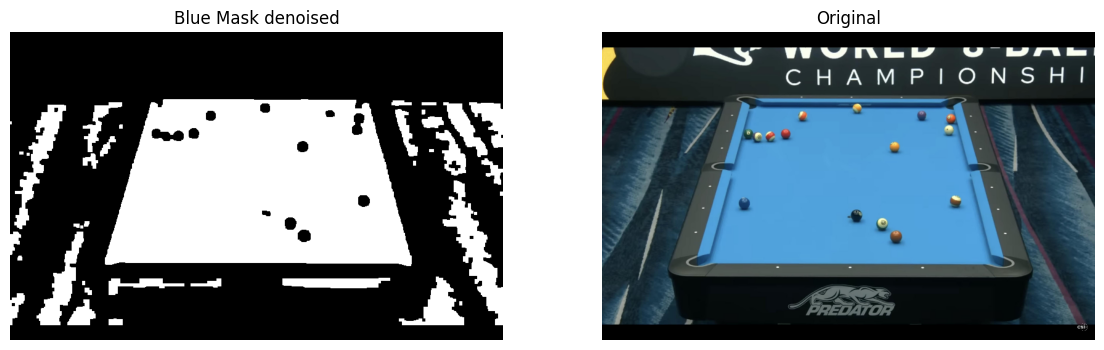

In [326]:
# clean the mask using morphological operations
kernel = np.ones((5, 5), np.uint8)
table_mask = cv2.morphologyEx(table_mask, cv2.MORPH_CLOSE, kernel)
table_mask = cv2.morphologyEx(table_mask, cv2.MORPH_OPEN, kernel)


f, axarr = plt.subplots(1, 2, figsize=(14, 4))

axarr[0].imshow(table_mask, cmap="gray")
axarr[0].set_title("Blue Mask denoised")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Original")
axarr[1].axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

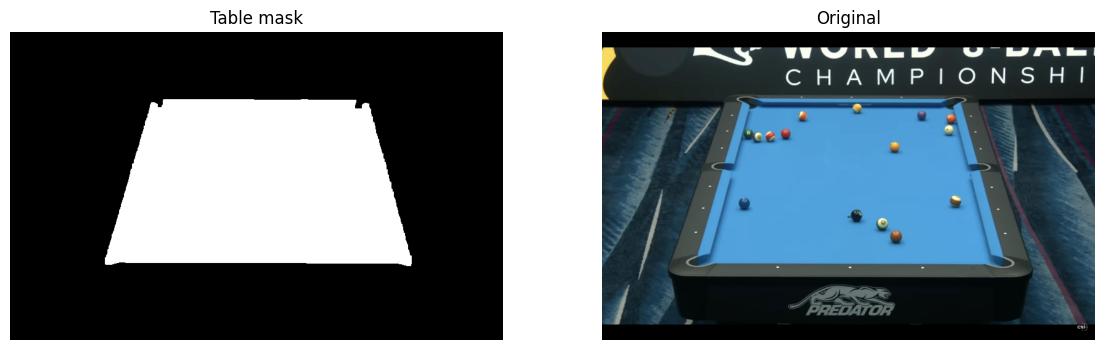

In [327]:
# finf the largest blue contour (should be the table surface)
contours, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)

# clean mask where only the table will be
surface_mask = np.zeros_like(table_mask)
cv2.drawContours(surface_mask, [largest_contour], -1, 255, -1)

f, axarr = plt.subplots(1, 2, figsize=(14, 4))

axarr[0].imshow(surface_mask, cmap="gray")
axarr[0].set_title("Table mask")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Original")
axarr[1].axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

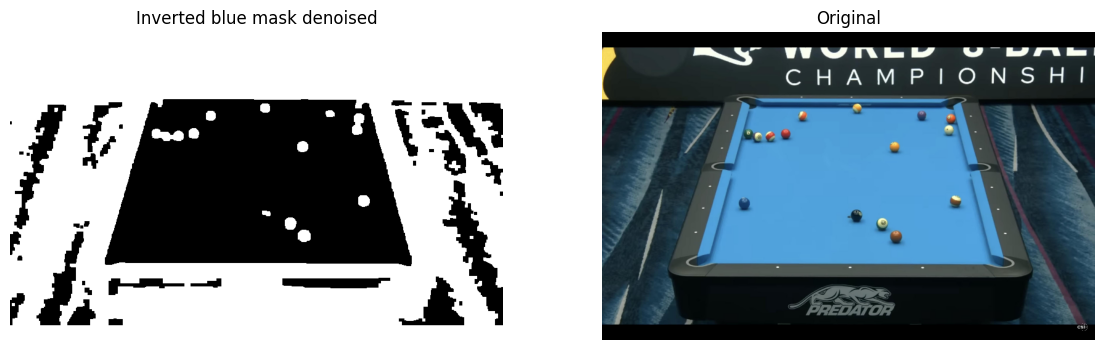

In [328]:
# invert the table mask to find non-blue objects
inverted_table = cv2.bitwise_not(table_mask)

f, axarr = plt.subplots(1, 2, figsize=(14, 4))

axarr[0].imshow(inverted_table, cmap="gray")
axarr[0].set_title("Inverted blue mask denoised")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Original")
axarr[1].axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

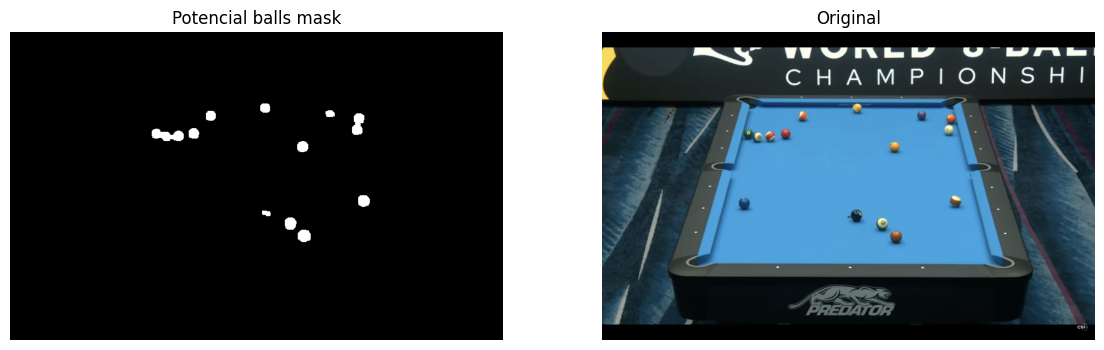

In [329]:
# keep the non-blue objects that are inside the table limits
potential_balls_mask = cv2.bitwise_and(inverted_table, inverted_table, mask=surface_mask)

f, axarr = plt.subplots(1, 2, figsize=(14, 4))

axarr[0].imshow(potential_balls_mask, cmap="gray")
axarr[0].set_title("Potencial balls mask")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Original")
axarr[1].axis("off")

(np.float64(-0.5), np.float64(799.5), np.float64(499.5), np.float64(-0.5))

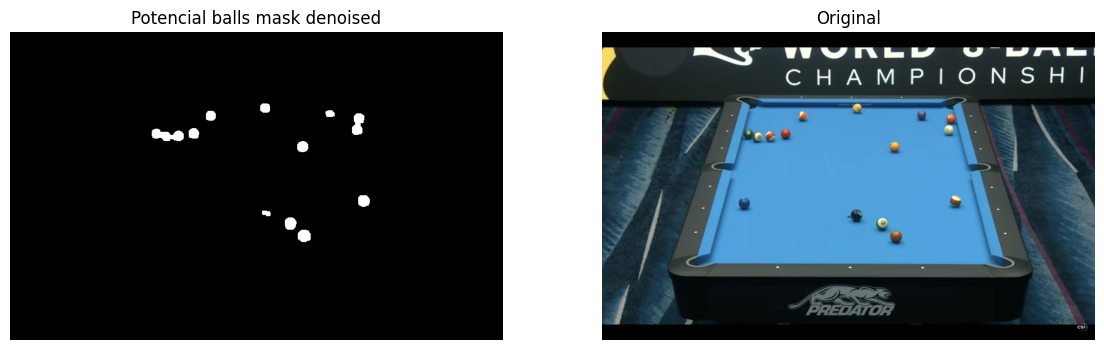

In [330]:
# clean up the noise in the potential balls mask
potential_balls_mask = cv2.morphologyEx(potential_balls_mask, cv2.MORPH_OPEN, kernel)

f, axarr = plt.subplots(1, 2, figsize=(14, 4))

axarr[0].imshow(potential_balls_mask, cmap="gray")
axarr[0].set_title("Potencial balls mask denoised")
axarr[0].axis("off")

axarr[1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Original")
axarr[1].axis("off")

(np.float64(-0.5), np.float64(3359.5), np.float64(2099.5), np.float64(-0.5))

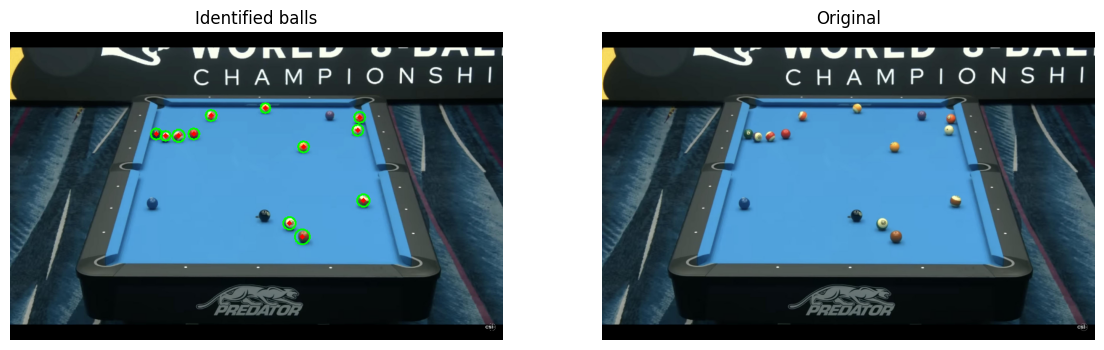

In [331]:

circles = cv2.HoughCircles(potential_balls_mask,cv2.HOUGH_GRADIENT_ALT, dp=1.5, minDist=10, param1=300, param2=0.1)

circles = np.int16(np.around(circles))

for i in circles[0,:]:
    # draw the outer circle
    cv2.circle(img,(i[0],i[1]),i[2],(0,255,0),2)
    # draw the center of the circle
    cv2.circle(img,(i[0],i[1]),2,(0,0,255),3)


f, axarr = plt.subplots(1, 2, figsize=(14, 4))

axarr[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Identified balls")
axarr[0].axis("off")


img_ori = cv2.imread(IMAGE_PATH)
axarr[1].imshow(cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Original")
axarr[1].axis("off")

In [332]:
print(f"Number of balls detected: {circles.shape[1]}")

Number of balls detected: 12


In [333]:
img_copy = cv2.imread(IMAGE_PATH)

#resize
height, width = img_copy.shape[:2]
img_copy = cv2.resize(img_copy, (800, int(800 * height / width)))

# find contours of the potential balls
ball_contours, _ = cv2.findContours(potential_balls_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

for cnt in ball_contours:
        area = cv2.contourArea(cnt)
        
        # ignore possible noise and massive counters that possibly represents shadows or cues
        if 50 < area < 4000:
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0:
                continue
            
            # check cirularity perfect circle = 1.0 using a lower threshold to account for angled camera that is present in some photos
            circularity = 4 * np.pi * (area / (perimeter * perimeter))
            
            if circularity > 0.5:
                x, y, w, h = cv2.boundingRect(cnt)
                
                # Draw the bounding box on the original image
                cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 0, 255), 2)
                
                # Optional: Draw the center point
                center = (x + w//2, y + h//2)
                cv2.circle(img_copy, center, 3, (0, 255, 0), -1)

(np.float64(-0.5), np.float64(3359.5), np.float64(2099.5), np.float64(-0.5))

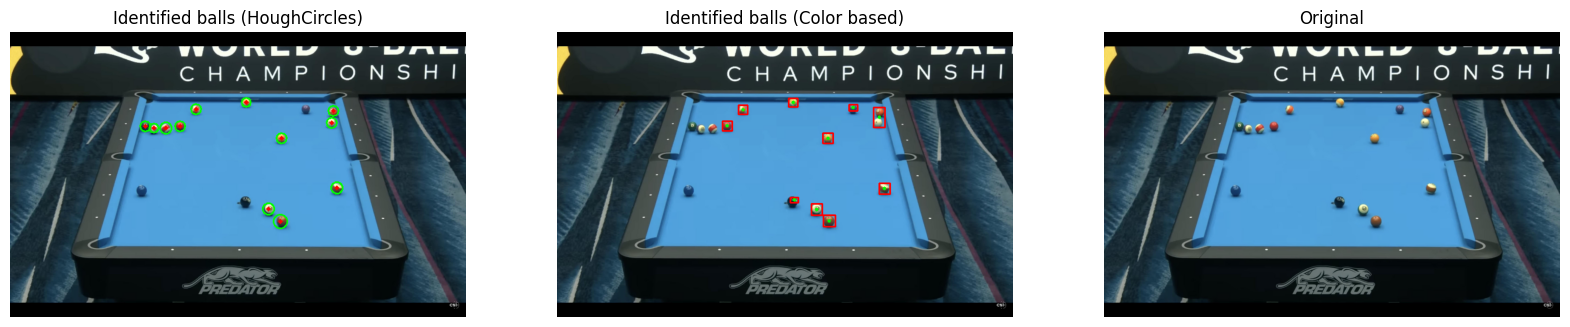

In [334]:
f, axarr = plt.subplots(1, 3, figsize=(20, 4))

axarr[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Identified balls (HoughCircles)")
axarr[0].axis("off")


img_2 = cv2.imread(IMAGE_PATH)
axarr[1].imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Identified balls (Color based)")
axarr[1].axis("off")

axarr[2].imshow(cv2.cvtColor(img_ori, cv2.COLOR_BGR2RGB))
axarr[2].set_title("Original")
axarr[2].axis("off")